# 🔋 Professional Time Series Analysis Pipeline
## Italy Solar Generation & Grid Load — 2016 (Hourly)

> **Dataset:** 8,784 hourly rows · 3 columns · Jan–Dec 2016  
> **Target:** `load_mw` (Italy national grid load in MW)  
> **Models:** Seasonal Naive → SARIMA → Linear Regression → XGBoost → **Prophet**

---
This notebook follows the **exact workflow** a professional data scientist uses:  
EDA → Stationarity → Decomposition → Feature Engineering → Multi-model comparison → Evaluation


## 📦 Step 0 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "statsmodels", "scikit-learn", "xgboost", "prophet",
                "matplotlib", "seaborn", "--quiet"], check=False)


CompletedProcess(args=['C:\\Users\\sajan\\AppData\\Local\\Programs\\Python\\Python314\\python.exe', '-m', 'pip', 'install', 'statsmodels', 'scikit-learn', 'xgboost', 'prophet', 'matplotlib', 'seaborn', '--quiet'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from prophet import Prophet

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#444466",
    "axes.labelcolor":  "#c8c8e8",
    "xtick.color":      "#c8c8e8",
    "ytick.color":      "#c8c8e8",
    "text.color":       "#c8c8e8",
    "grid.color":       "#2a2d4a",
    "grid.linewidth":   0.5,
    "legend.facecolor": "#1a1d2e",
    "legend.edgecolor": "#444466",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "figure.dpi":       110,
})
COLORS = ["#7c6af7", "#f7a26a", "#4ecdc4", "#f94144", "#43aa8b"]
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 📂 Step 1 — Load & Parse Data
**What a pro does:**  
- Parse timestamp as a real `DatetimeIndex` (not a string)  
- Call `asfreq("h")` to **enforce uniform hourly cadence** — gaps will break SARIMA and lag features  
- Inspect shape, dtypes, null counts, and date range *before* touching a model  


In [3]:
DATA_PATH = "TimeSeries_TotalSolarGen_and_Load_IT_2016.csv"  # update path if needed

df = pd.read_csv(DATA_PATH, parse_dates=["utc_timestamp"], index_col="utc_timestamp")
df.index = df.index.tz_localize(None)   # strip timezone for clean datetime math
df.columns = ["load_mw", "solar_mw"]
df = df.asfreq("h")                     # enforce hourly — fills gaps with NaN

print("Shape          :", df.shape)
print("Date range     :", df.index.min(), "→", df.index.max())
print("Null counts    :")
print(df.isnull().sum())
print()
print(df.describe().round(0))


Shape          : (8784, 2)
Date range     : 2016-01-01 00:00:00 → 2016-12-31 23:00:00
Null counts    :
load_mw     72
solar_mw     0
dtype: int64

       load_mw  solar_mw
count   8712.0    8784.0
mean   32262.0    2050.0
std     7289.0    2846.0
min    16716.0       0.0
25%    25910.0       0.0
50%    31654.0      68.0
75%    38686.0    3924.0
max    48986.0   15824.0


In [4]:
# ── Missing value handling ─────────────────────────────────────────────────
# WHY time-interpolation: load is a smooth continuous signal.
# Time-interpolation fits a straight line between known values.
# Forward-fill would repeat the same stale reading — wrong for a cyclical series.

df["load_mw"] = df["load_mw"].interpolate(method="time")
print(f"After interpolation — nulls: {df['load_mw'].isnull().sum()}")


After interpolation — nulls: 0


## 📊 Step 2 — Exploratory Data Analysis (EDA)
**What a pro does:**  
- Visualise the *full year* to spot trends, anomalies, missing blocks  
- Look at the **average daily profile** (hour-of-day) — does load peak at evening? Does solar peak at noon?  
- Check **monthly patterns** — is there a summer/winter split?  
- Examine **distributions** — are there outliers that need handling?  


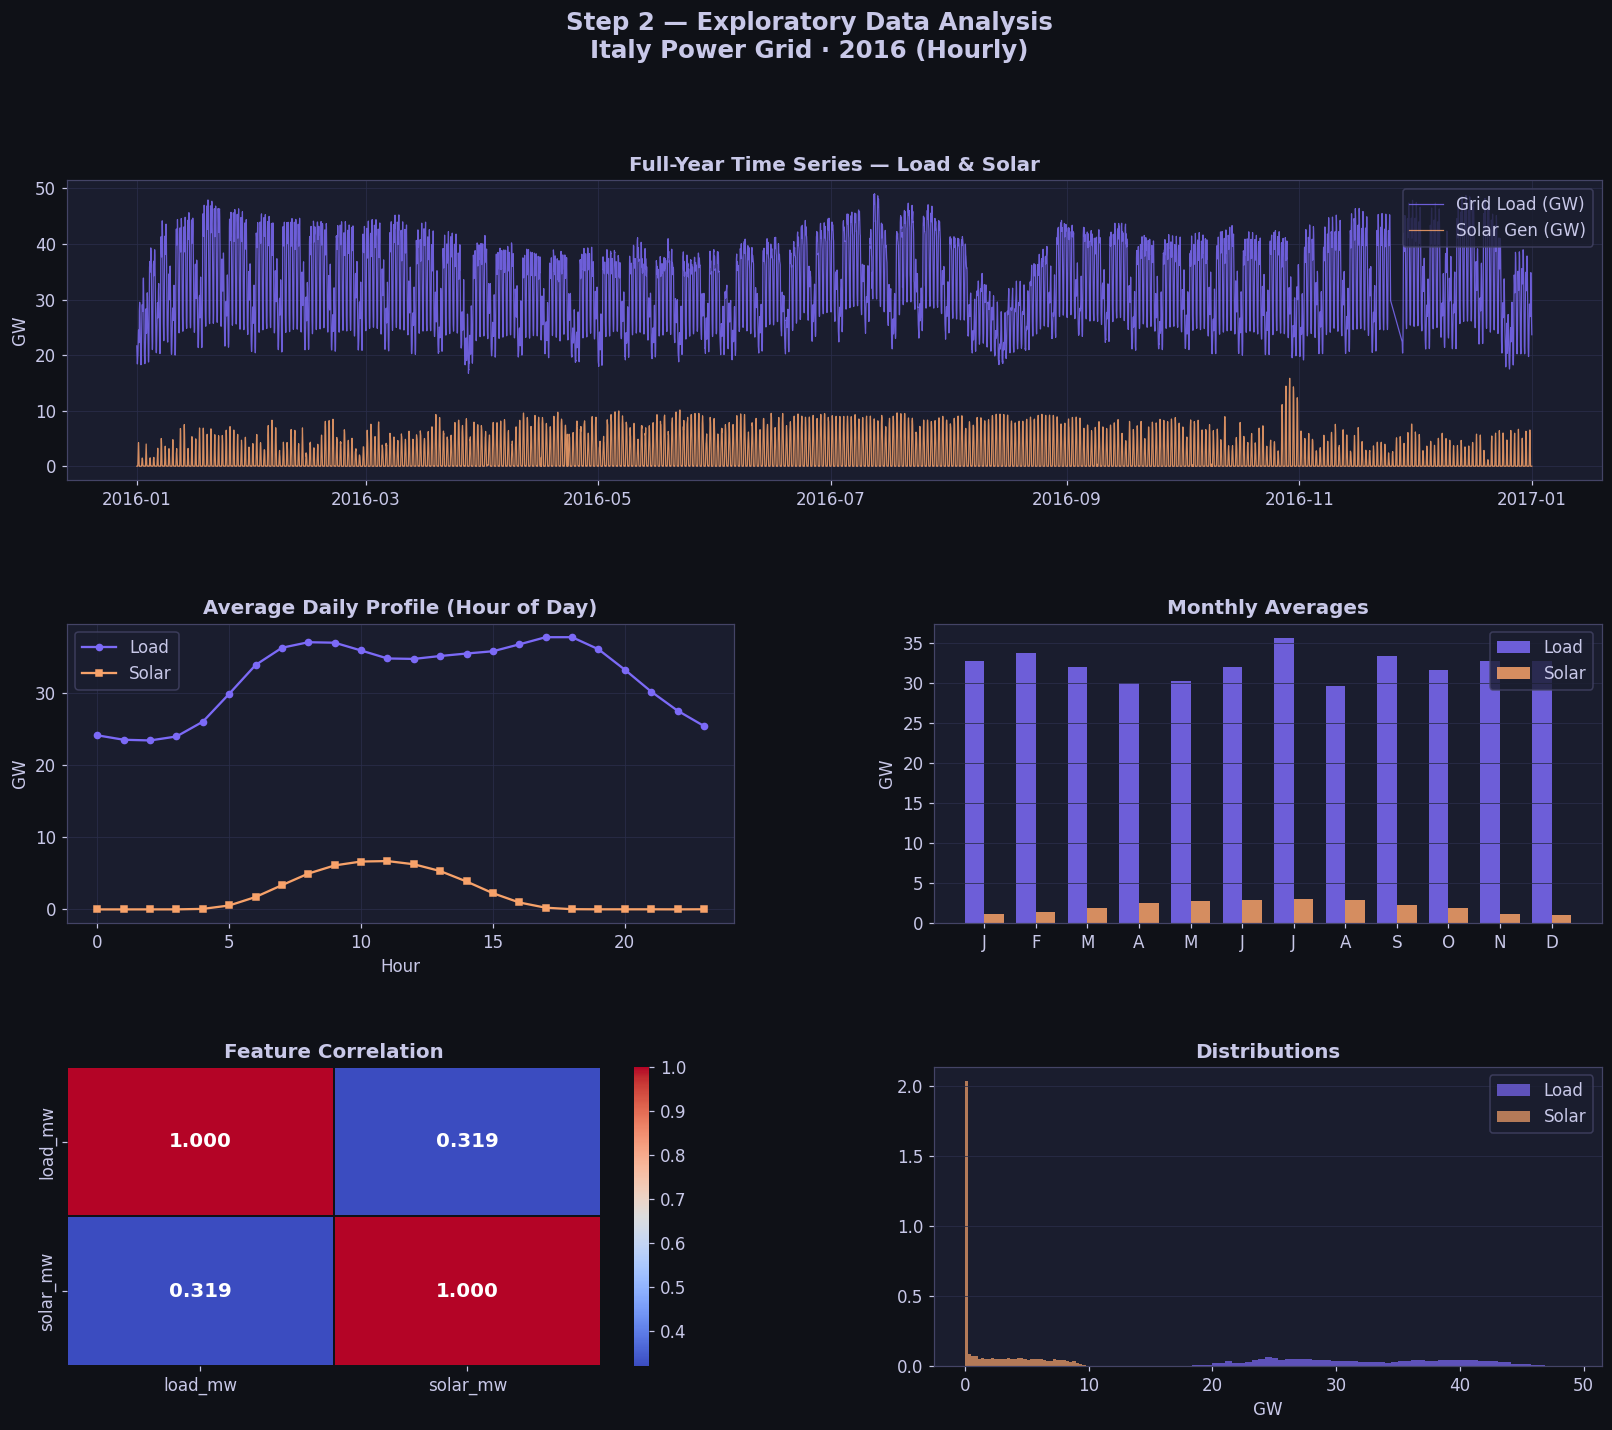


Peak load hour : 18:00
Peak solar hour: 11:00


In [5]:
df["hour"]      = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"]     = df.index.month

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Step 2 — Exploratory Data Analysis\nItaly Power Grid · 2016 (Hourly)",
             fontsize=16, y=0.99, fontweight="bold")
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.3)

# ── 1. Full year overview ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df["load_mw"]/1000,  color=COLORS[0], lw=0.8, alpha=0.85, label="Grid Load (GW)")
ax1.plot(df.index, df["solar_mw"]/1000, color=COLORS[1], lw=0.8, alpha=0.85, label="Solar Gen (GW)")
ax1.set_title("Full-Year Time Series — Load & Solar")
ax1.set_ylabel("GW"); ax1.legend(); ax1.grid(True)

# ── 2. Average daily profile ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
hourly_avg = df.groupby("hour")[["load_mw","solar_mw"]].mean()
ax2.plot(hourly_avg.index, hourly_avg["load_mw"]/1000,  color=COLORS[0], marker="o", ms=4, label="Load")
ax2.plot(hourly_avg.index, hourly_avg["solar_mw"]/1000, color=COLORS[1], marker="s", ms=4, label="Solar")
ax2.set_title("Average Daily Profile (Hour of Day)")
ax2.set_xlabel("Hour"); ax2.set_ylabel("GW"); ax2.legend(); ax2.grid(True)
# NOTE: load peaks ~19-20h (evening), solar peaks ~12h (noon) → classic duck curve

# ── 3. Monthly averages ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
monthly = df.groupby("month")[["load_mw","solar_mw"]].mean()
x = np.arange(12); w = 0.38
ax3.bar(x-w/2, monthly["load_mw"]/1000,  width=w, color=COLORS[0], alpha=0.85, label="Load")
ax3.bar(x+w/2, monthly["solar_mw"]/1000, width=w, color=COLORS[1], alpha=0.85, label="Solar")
ax3.set_xticks(x); ax3.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax3.set_title("Monthly Averages"); ax3.set_ylabel("GW"); ax3.legend(); ax3.grid(True, axis="y")

# ── 4. Correlation heatmap ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
sns.heatmap(df[["load_mw","solar_mw"]].corr(), annot=True, fmt=".3f",
            cmap="coolwarm", ax=ax4, linewidths=1, linecolor="#0f1117",
            annot_kws={"size":13, "weight":"bold"})
ax4.set_title("Feature Correlation")

# ── 5. Distributions ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df["load_mw"]/1000,  bins=60, color=COLORS[0], alpha=0.7, label="Load",  density=True)
ax5.hist(df["solar_mw"]/1000, bins=60, color=COLORS[1], alpha=0.7, label="Solar", density=True)
ax5.set_title("Distributions"); ax5.set_xlabel("GW"); ax5.legend(); ax5.grid(True, axis="y")

plt.show()
print(f"\nPeak load hour : {hourly_avg['load_mw'].idxmax()}:00")
print(f"Peak solar hour: {hourly_avg['solar_mw'].idxmax()}:00")


## 🔬 Step 3 — Stationarity Tests (ADF + KPSS)
**What a pro does:**  
ARIMA/SARIMA requires a **stationary** series (constant mean & variance over time).  
Two tests are used together:

| Test | H₀ (null hypothesis) | Reject if |
|------|----------------------|-----------|
| **ADF** | Series is non-stationary | p < 0.05 → **stationary** ✅ |
| **KPSS** | Series is stationary | p < 0.05 → **non-stationary** ❌ |

If both agree the series is stationary → `d=0` (no differencing needed in ARIMA).


In [6]:
series = df["load_mw"]

adf_stat, adf_p, adf_lags, adf_n, adf_cv, _ = adfuller(series, autolag="AIC")
kpss_stat, kpss_p, kpss_lags, kpss_cv       = kpss(series, regression="c", nlags="auto")

print("=" * 50)
print("ADF Test  (H₀: Non-stationary)")
print(f"  Statistic : {adf_stat:.4f}")
print(f"  p-value   : {adf_p:.6f}")
print(f"  Verdict   : {'✅ STATIONARY (d=0)' if adf_p < 0.05 else '❌ NON-STATIONARY (need d≥1)'}")
print()
print("KPSS Test (H₀: Stationary)")
print(f"  Statistic : {kpss_stat:.4f}")
print(f"  p-value   : {kpss_p:.4f}")
print(f"  Verdict   : {'✅ STATIONARY' if kpss_p > 0.05 else '❌ NON-STATIONARY'}")
print("=" * 50)
print("\n→ Both tests agree: series is STATIONARY → use d=0 in ARIMA")


ADF Test  (H₀: Non-stationary)
  Statistic : -12.0144
  p-value   : 0.000000
  Verdict   : ✅ STATIONARY (d=0)

KPSS Test (H₀: Stationary)
  Statistic : 0.1966
  p-value   : 0.1000
  Verdict   : ✅ STATIONARY

→ Both tests agree: series is STATIONARY → use d=0 in ARIMA


C:\Users\sajan\AppData\Local\Temp\ipykernel_13680\3296270581.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv       = kpss(series, regression="c", nlags="auto")


## 🔄 Step 4 — Seasonal Decomposition
**What a pro does:**  
Split the series into 3 components using `period=168` (24h × 7 days = weekly cycle):
- **Trend** — long-run direction (is load growing through the year?)
- **Seasonal** — repeating weekly pattern
- **Residual** — what's left after removing trend & season (should look like noise)

If residuals show structure → model is missing something → add more features.


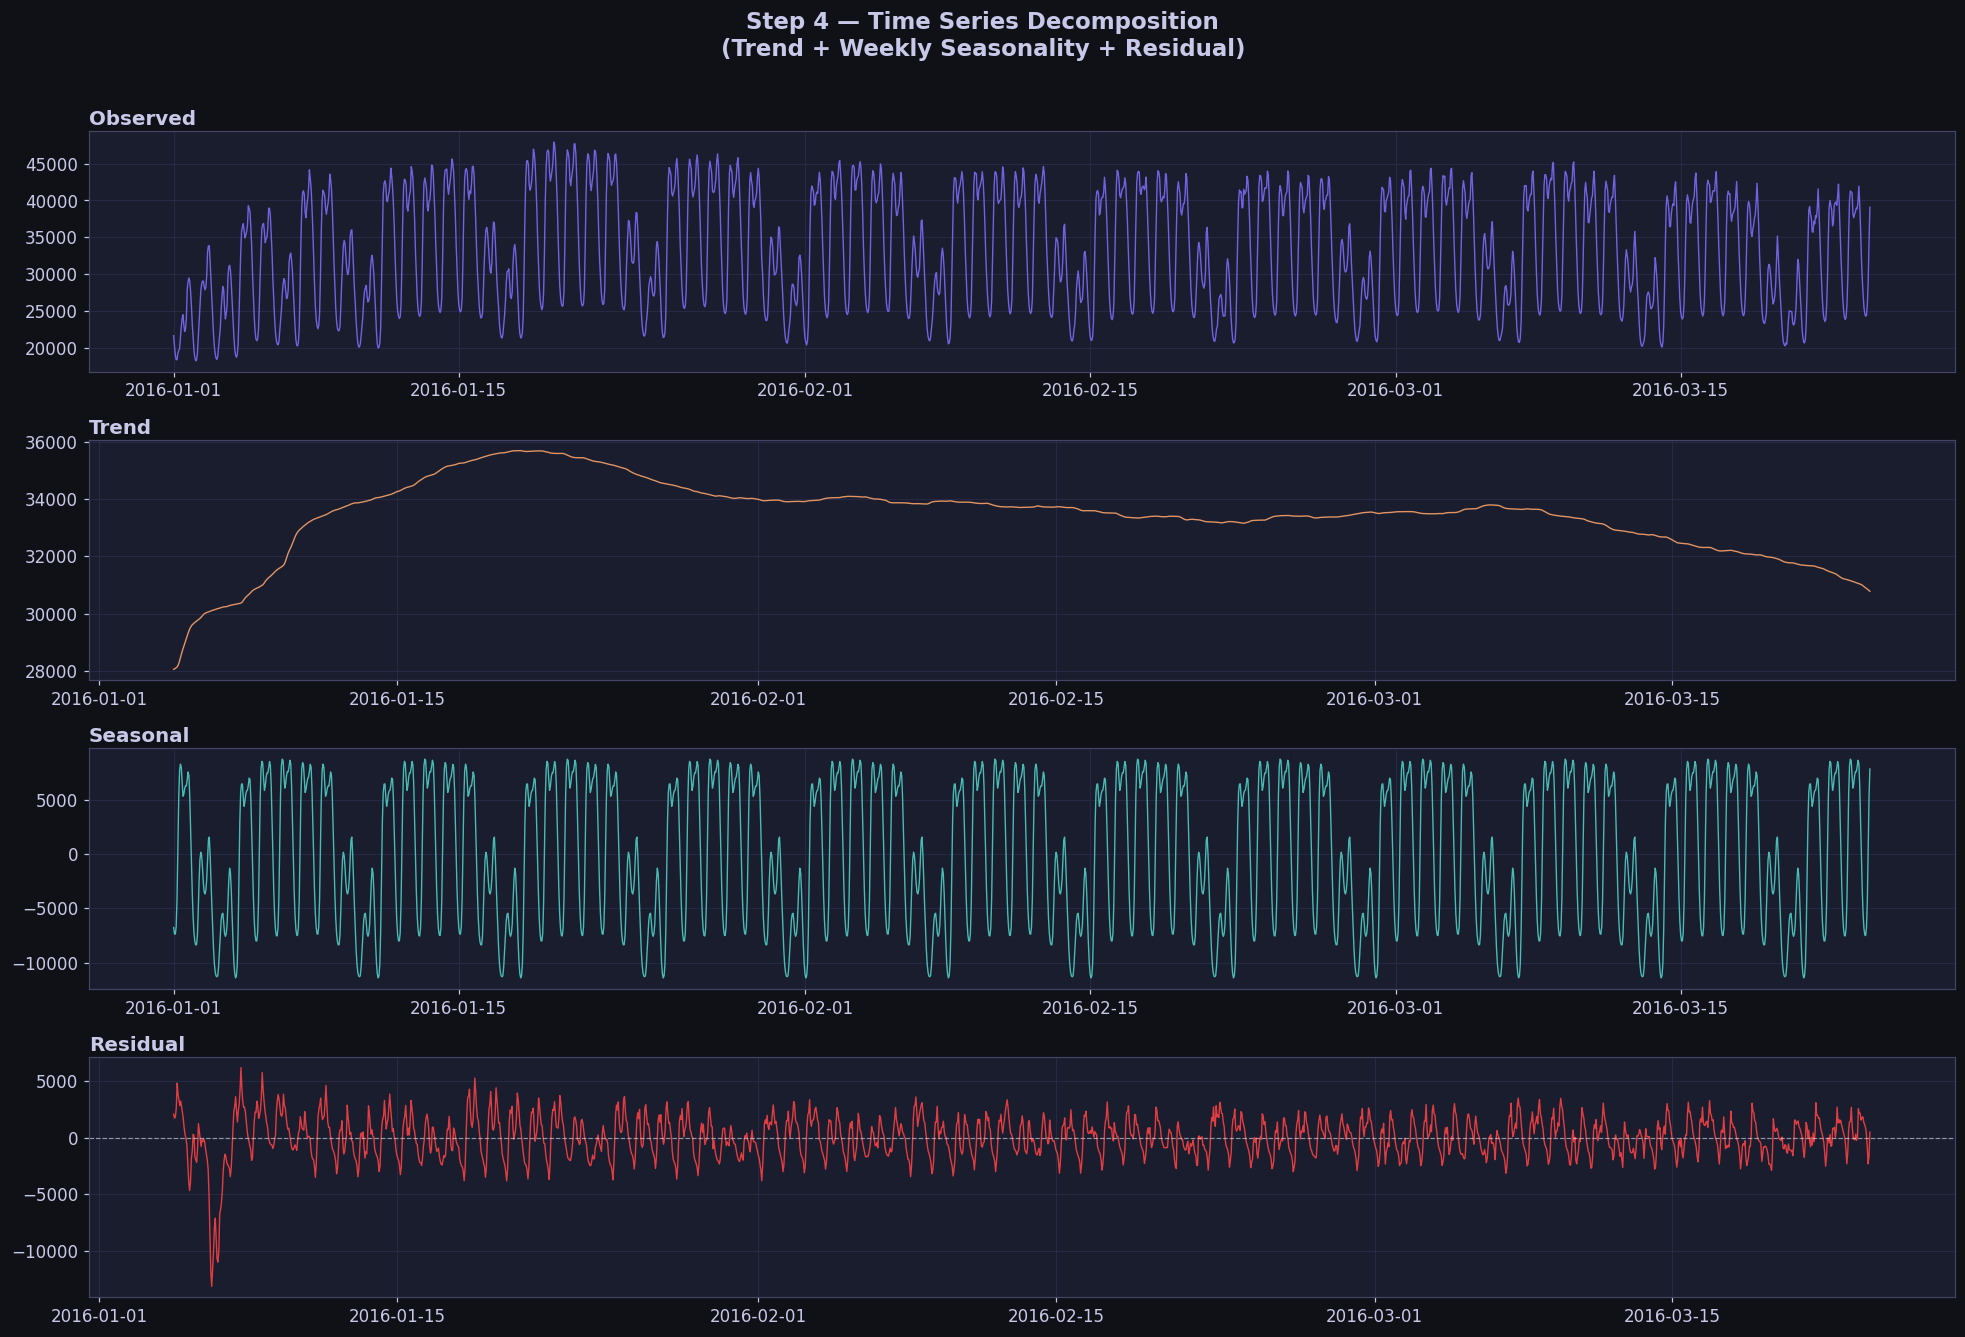

In [7]:
decomp = seasonal_decompose(series, model="additive", period=168)

fig, axes = plt.subplots(4, 1, figsize=(18, 12))
fig.suptitle("Step 4 — Time Series Decomposition\n(Trend + Weekly Seasonality + Residual)",
             fontsize=15, fontweight="bold", y=1.01)
fig.patch.set_facecolor("#0f1117")

components = [
    (decomp.observed,  "Observed",  COLORS[0]),
    (decomp.trend,     "Trend",     COLORS[1]),
    (decomp.seasonal,  "Seasonal",  COLORS[2]),
    (decomp.resid,     "Residual",  COLORS[3]),
]
# Show first 2000 hours (≈ 12 weeks) so patterns are visible
for ax, (comp, label, color) in zip(axes, components):
    ax.plot(comp.index[:2000], comp.iloc[:2000], color=color, lw=0.9, alpha=0.9)
    ax.set_title(label, loc="left", pad=4)
    ax.grid(True)
    if label == "Residual":
        ax.axhline(0, color="white", lw=0.8, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 📈 Step 5 — ACF & PACF (Choose ARIMA p, q Orders)
**What a pro does:**  
These plots tell you which ARIMA parameters to try *before* fitting:
- **PACF** — partial autocorrelation. Cuts off at lag **p** → use AR(p)
- **ACF** — autocorrelation. Cuts off at lag **q** → use MA(q)
- Spikes at multiples of 24 → strong daily seasonality → use `s=24` in SARIMA


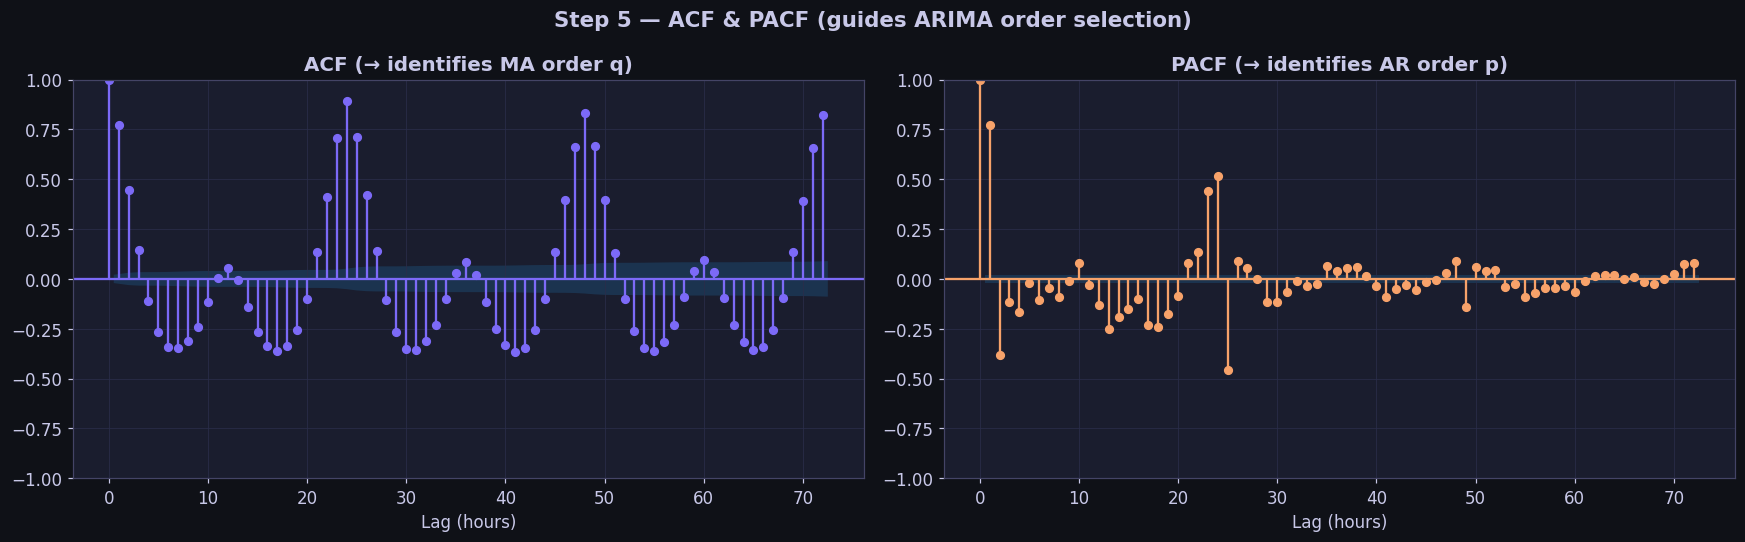

Interpretation: PACF cuts off ~lag 2 → p=2 | ACF pattern → q=1
Spikes at 24, 48, 72 → daily seasonality → use s=24 in SARIMA


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Step 5 — ACF & PACF (guides ARIMA order selection)",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#0f1117")
for ax in axes: ax.set_facecolor("#1a1d2e")

diff_series = series.diff().dropna()

plot_acf(diff_series, lags=72, ax=axes[0], alpha=0.05,
         title="ACF (→ identifies MA order q)",
         vlines_kwargs={"colors": COLORS[0]}, color=COLORS[0])
plot_pacf(diff_series, lags=72, ax=axes[1], alpha=0.05,
          method="ywm", title="PACF (→ identifies AR order p)",
          vlines_kwargs={"colors": COLORS[1]}, color=COLORS[1])

for ax in axes:
    ax.set_xlabel("Lag (hours)"); ax.grid(True)

plt.tight_layout()
plt.show()
print("Interpretation: PACF cuts off ~lag 2 → p=2 | ACF pattern → q=1")
print("Spikes at 24, 48, 72 → daily seasonality → use s=24 in SARIMA")


## ✂️ Step 6 — Train / Test Split
**What a pro does:**  
**NEVER shuffle time series data.** Always split chronologically.  
We hold out the **last 7 days (168 hours)** as the test set — the model has never seen these.


Training set : 8,616 hours  (2016-01-01 → 2016-12-24)
Test set     : 168 hours  (2016-12-25 → 2016-12-31)


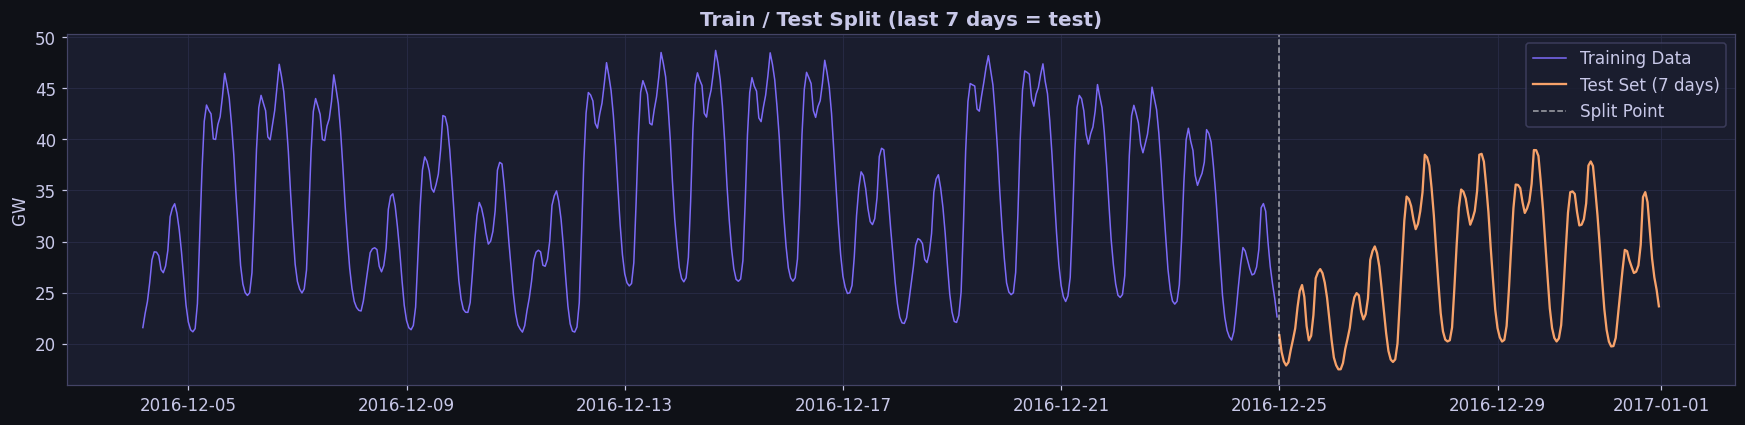

In [9]:
TEST_HOURS = 24 * 7   # 1 week

train = series.iloc[:-TEST_HOURS]
test  = series.iloc[-TEST_HOURS:]

print(f"Training set : {len(train):,} hours  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test set     : {len(test):,} hours  ({test.index.min().date()} → {test.index.max().date()})")

# Quick visual
fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")
ax.plot(train.index[-500:], train.iloc[-500:]/1000, color=COLORS[0], lw=1,   label="Training Data")
ax.plot(test.index,         test/1000,              color=COLORS[1], lw=1.5, label="Test Set (7 days)")
ax.axvline(test.index[0], color="white", ls="--", lw=1, alpha=0.6, label="Split Point")
ax.set_title("Train / Test Split (last 7 days = test)"); ax.set_ylabel("GW")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# Evaluation helper used across all models
results = {}

def evaluate(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    results[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "pred": predicted}
    print(f"[{name:<22s}]  MAE={mae:6.0f} MW  |  RMSE={rmse:6.0f} MW  |  MAPE={mape:.2f}%")
    return mae, rmse, mape


## 🎯 Step 7 — Baseline: Seasonal Naive
**What a pro does:**  
Always start with the dumbest possible model.  
**Seasonal Naive = "Predict the same value as the same hour one week ago."**  
If your fancy model can't beat this, something is wrong.  
This sets the **performance floor** — the minimum you must beat.


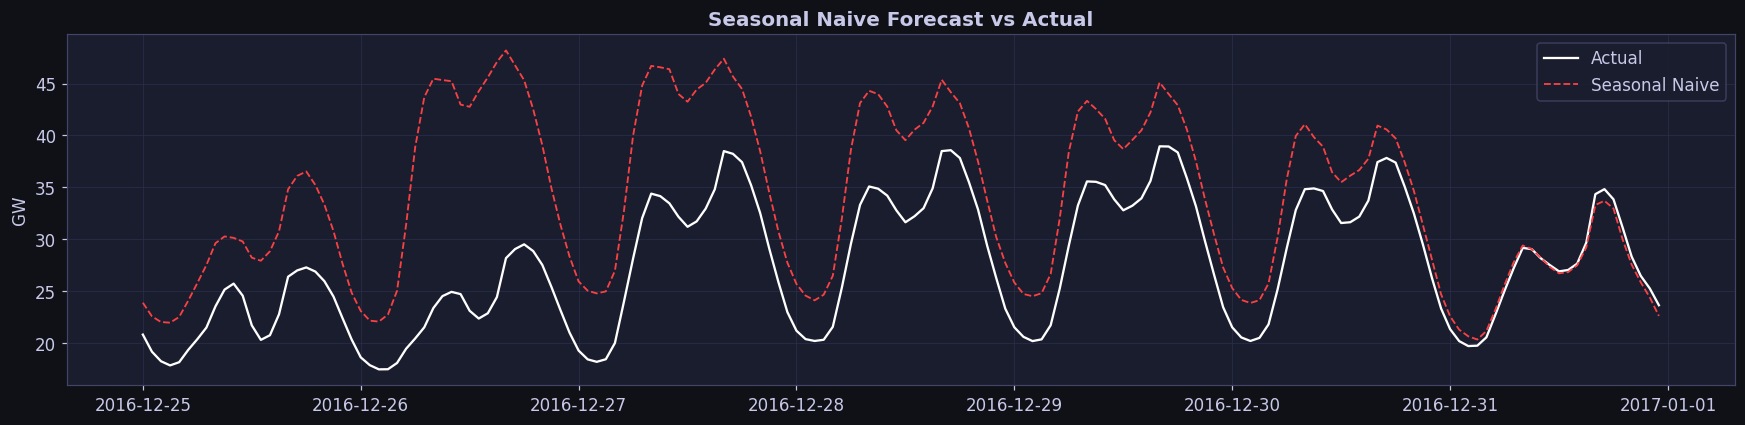

[Seasonal Naive        ]  MAE=  6585 MW  |  RMSE=  8295 MW  |  MAPE=25.06%


(6584.541666666667,
 np.float64(8294.533148333878),
 np.float64(25.060018945300776))

In [10]:
# Predict last week same hours
naive_pred = train.iloc[-TEST_HOURS:].values

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")
ax.plot(test.index, test.values/1000,   color="white",    lw=1.5, label="Actual")
ax.plot(test.index, naive_pred/1000,    color=COLORS[3],  lw=1.2, ls="--", label="Seasonal Naive")
ax.set_title("Seasonal Naive Forecast vs Actual"); ax.set_ylabel("GW")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

evaluate("Seasonal Naive", test.values, naive_pred)


## 📐 Step 8 — SARIMA Model
**What a pro does:**  
SARIMA = **S**easonal **A**uto-**R**egressive **I**ntegrated **M**oving **A**verage.  
Parameters from our ACF/PACF analysis:  
- `order=(2, 0, 1)` → AR(2), no differencing (d=0), MA(1)  
- `seasonal_order=(1, 1, 0, 24)` → seasonal AR(1), seasonal differencing, period=24h  

SARIMA is the classical statistical benchmark — solid, interpretable, no feature engineering needed.


Fitting SARIMA(2,0,1)(1,1,0)[24] — this may take ~30 seconds...


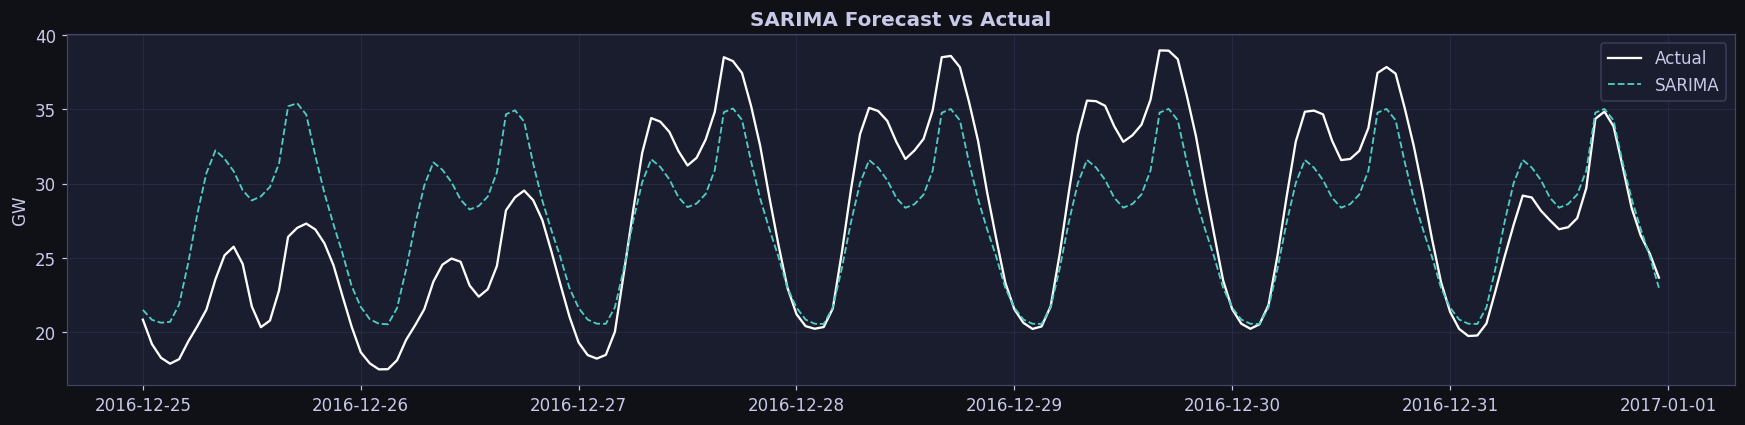

[SARIMA                ]  MAE=  3055 MW  |  RMSE=  3767 MW  |  MAPE=11.47%


(3054.5097197625264,
 np.float64(3766.6250895224202),
 np.float64(11.46700504547868))

In [11]:
print("Fitting SARIMA(2,0,1)(1,1,0)[24] — this may take ~30 seconds...")

sarima_model = SARIMAX(
    train,
    order=(2, 0, 1),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit   = sarima_model.fit(disp=False)
sarima_pred  = sarima_fit.forecast(steps=TEST_HOURS)

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")
ax.plot(test.index, test.values/1000,         color="white",   lw=1.5, label="Actual")
ax.plot(test.index, sarima_pred.values/1000,  color=COLORS[2], lw=1.2, ls="--", label="SARIMA")
ax.set_title("SARIMA Forecast vs Actual"); ax.set_ylabel("GW")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

evaluate("SARIMA", test.values, sarima_pred.values)


## 🛠️ Step 9 — Feature Engineering for ML Models
**What a pro does:**  
ML models do NOT understand time automatically — you must encode it as features:

| Feature | Why it helps |
|---------|-------------|
| `hour`, `dayofweek`, `month` | Calendar cycles (morning peak, weekday vs weekend) |
| `is_weekend` | Weekends have different load profiles |
| `lag_24h`, `lag_48h`, `lag_168h` | Load yesterday same hour, day before, last week same hour |
| `rolling_24h_mean` | Smooth local trend over past day |
| `rolling_7d_mean` | Weekly baseline context |

**Key rule:** All lags/rolling windows must use `.shift(n)` — you can only use *past* values to predict the future.


In [12]:
def make_features(s: pd.Series) -> pd.DataFrame:
    f = pd.DataFrame(index=s.index)
    # Calendar features
    f["hour"]              = s.index.hour
    f["dayofweek"]         = s.index.dayofweek
    f["month"]             = s.index.month
    f["is_weekend"]        = (s.index.dayofweek >= 5).astype(int)
    # Lag features (past values)
    f["lag_24h"]           = s.shift(24)    # same hour yesterday
    f["lag_48h"]           = s.shift(48)    # same hour 2 days ago
    f["lag_168h"]          = s.shift(168)   # same hour last week
    # Rolling statistics (smooth context)
    f["rolling_24h_mean"]  = s.shift(1).rolling(24).mean()
    f["rolling_7d_mean"]   = s.shift(1).rolling(168).mean()
    f["target"]            = s
    return f.dropna()

full_feat = make_features(series)
split_idx = len(full_feat) - TEST_HOURS

X_train = full_feat.iloc[:split_idx].drop("target", axis=1)
y_train = full_feat.iloc[:split_idx]["target"]
X_test  = full_feat.iloc[split_idx:].drop("target", axis=1)
y_test  = full_feat.iloc[split_idx:]["target"]

print("Feature matrix shape:", X_train.shape)
print(X_train.head(3).round(0))


Feature matrix shape: (8448, 9)
                     hour  dayofweek  month  is_weekend  lag_24h  lag_48h  \
utc_timestamp                                                               
2016-01-08 00:00:00     0          4      1           0  21226.0  22129.0   
2016-01-08 01:00:00     1          4      1           0  20395.0  21058.0   
2016-01-08 02:00:00     2          4      1           0  20269.0  20533.0   

                     lag_168h  rolling_24h_mean  rolling_7d_mean  
utc_timestamp                                                     
2016-01-08 00:00:00   21665.0           34095.0          28041.0  
2016-01-08 01:00:00   20260.0           34207.0          28055.0  
2016-01-08 02:00:00   19056.0           34316.0          28071.0  


## 📏 Step 10 — Linear Regression
**What a pro does:**  
Run the simple ML baseline first. If Linear Regression is competitive with XGBoost,  
the relationship is mostly linear — you don't need the complexity.  
It also gives interpretable coefficients: which features matter most?


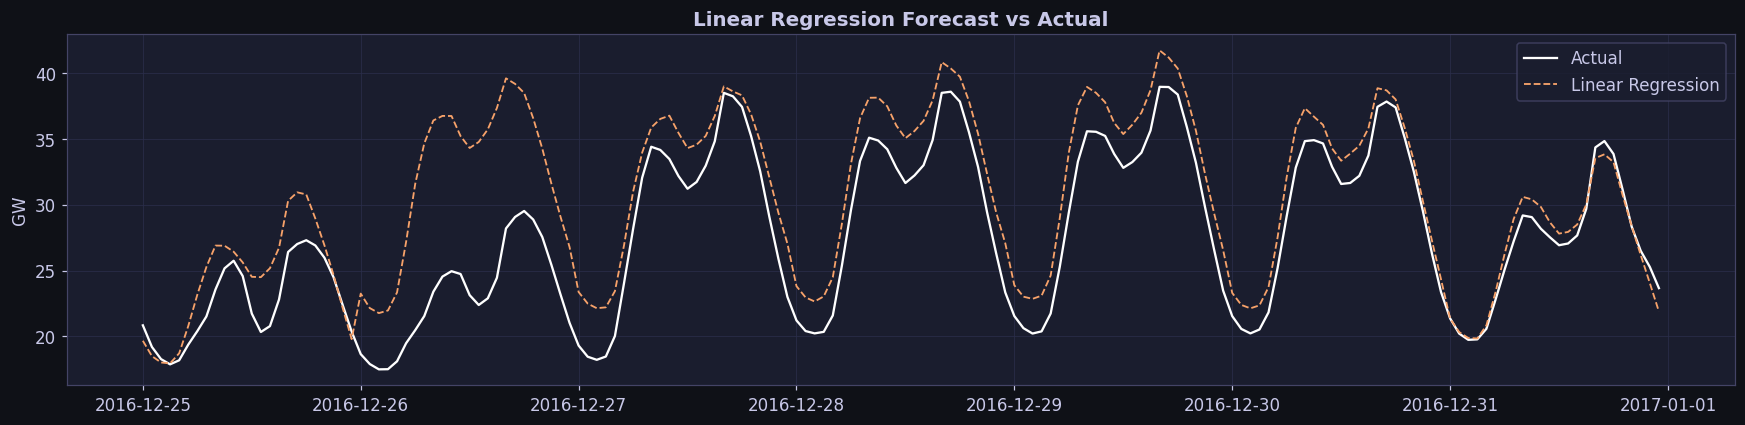

[Linear Regression     ]  MAE=  3111 MW  |  RMSE=  4238 MW  |  MAPE=12.33%

Top coefficients:
dayofweek          -1009.1
is_weekend           386.7
hour                  21.5
month                -15.1
lag_168h               0.5
lag_24h                0.3
rolling_24h_mean       0.2
rolling_7d_mean       -0.2
lag_48h                0.2
dtype: float64


In [13]:
lr      = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")
ax.plot(y_test.index, y_test.values/1000, color="white",   lw=1.5, label="Actual")
ax.plot(y_test.index, lr_pred/1000,       color=COLORS[1], lw=1.2, ls="--", label="Linear Regression")
ax.set_title("Linear Regression Forecast vs Actual"); ax.set_ylabel("GW")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

evaluate("Linear Regression", y_test.values, lr_pred)

# Coefficients
coef_df = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print("\nTop coefficients:")
print(coef_df.round(1))


## ⚡ Step 11 — XGBoost (Gradient Boosted Trees)
**What a pro does:**  
XGBoost handles non-linear relationships, feature interactions, and is robust to outliers.  
It almost always outperforms Linear Regression on structured tabular time series data.

**Key hyperparameters explained:**
- `n_estimators=400` — number of trees (more = better up to overfitting)
- `max_depth=6` — tree complexity (deeper = more non-linear, risk of overfit)
- `learning_rate=0.05` — shrinks each tree's contribution (slow + accurate)
- `subsample=0.8` — use 80% of rows per tree (reduces variance)
- `colsample_bytree=0.8` — use 80% of features per tree (reduces variance)


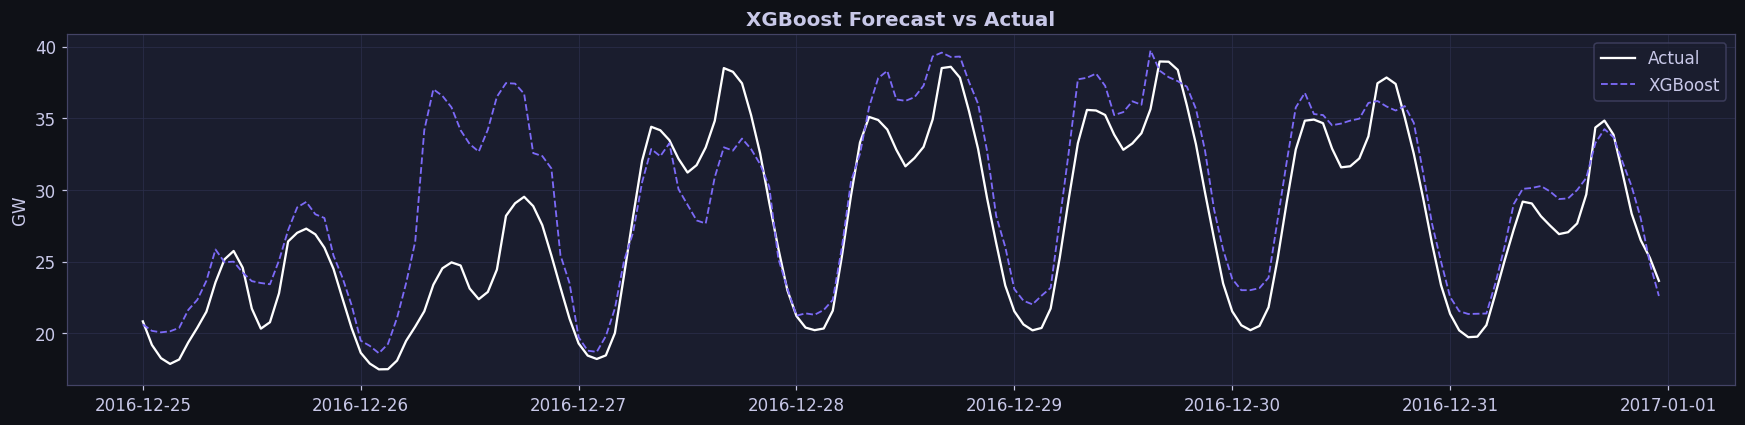

[XGBoost               ]  MAE=  2607 MW  |  RMSE=  3654 MW  |  MAPE=9.98%


(2607.1204194568454,
 np.float64(3654.3279428789224),
 np.float64(9.979684591941137))

In [14]:
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")
ax.plot(y_test.index, y_test.values/1000, color="white",   lw=1.5, label="Actual")
ax.plot(y_test.index, xgb_pred/1000,      color=COLORS[0], lw=1.2, ls="--", label="XGBoost")
ax.set_title("XGBoost Forecast vs Actual"); ax.set_ylabel("GW")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

evaluate("XGBoost", y_test.values, xgb_pred)


## 🔮 Step 12 — Prophet (Facebook / Meta)
**What a pro does:**  
Prophet is a **decomposable additive model** from Meta that automatically handles:
- **Multiple seasonalities** (daily + weekly + yearly) without any manual ACF/PACF
- **Holiday effects** (can add custom holiday calendars)
- **Missing data** natively
- **Trend changepoints** (detects structural breaks automatically)

Prophet is excellent when you have several seasons and want interpretable components.  
It requires a DataFrame with columns `ds` (date) and `y` (target).


16:43:43 - cmdstanpy - INFO - Chain [1] start processing
16:43:45 - cmdstanpy - INFO - Chain [1] done processing


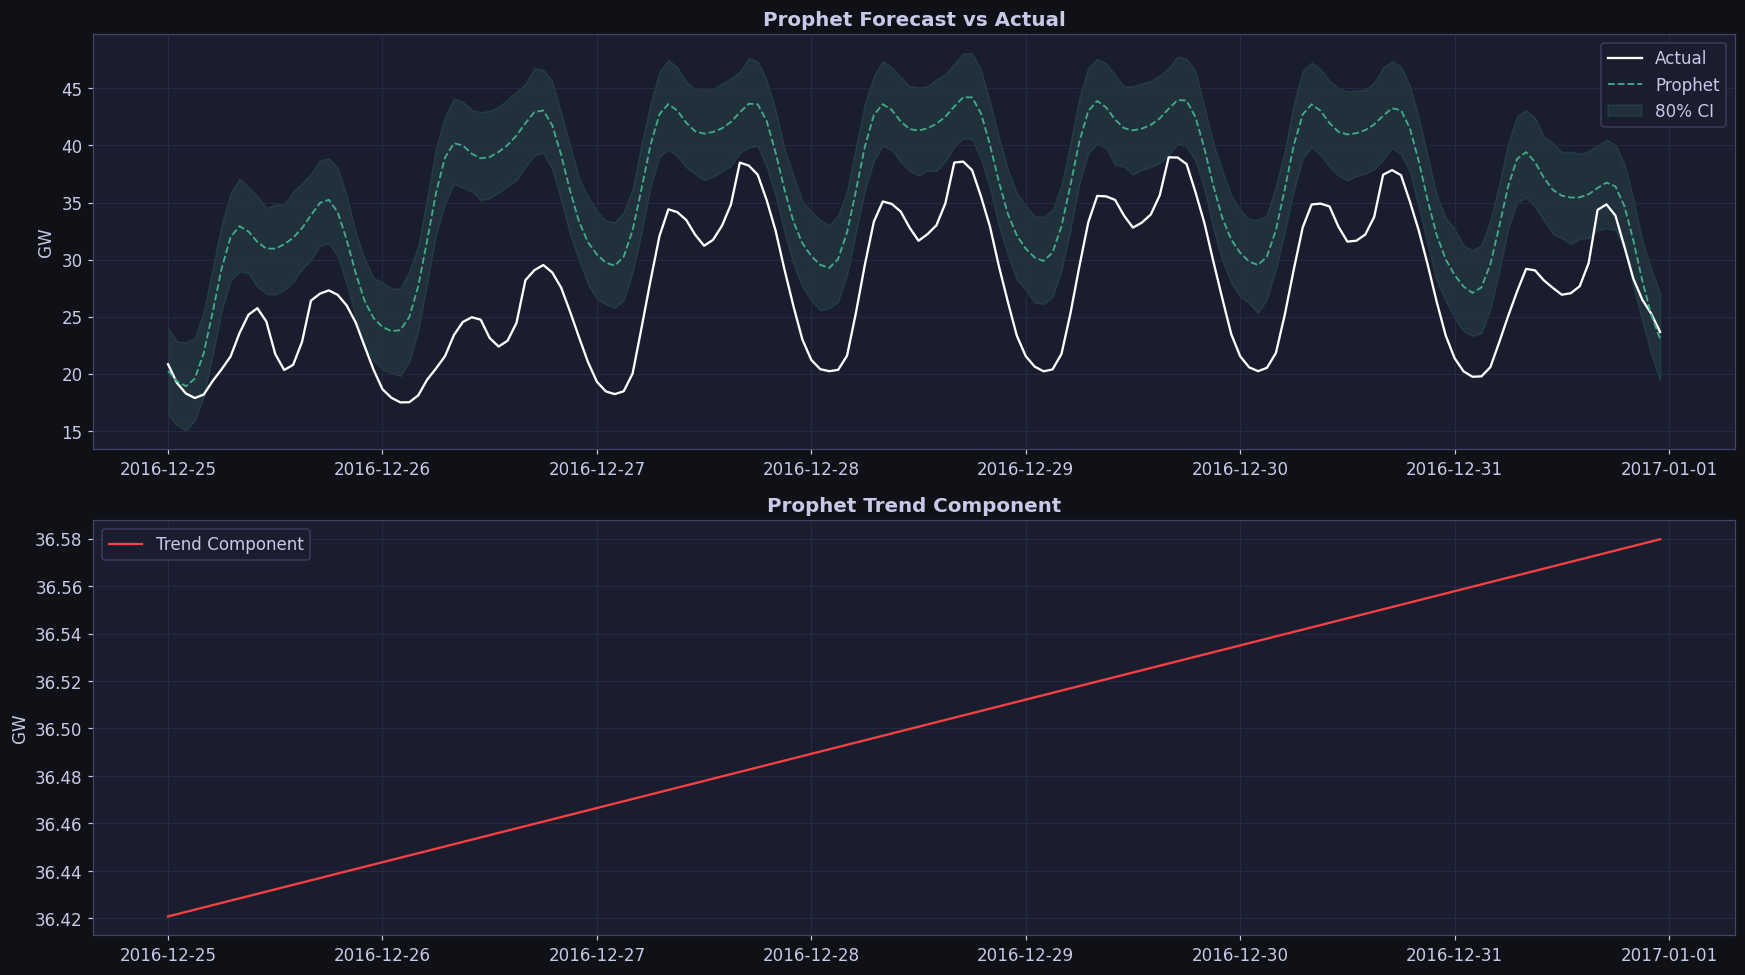

[Prophet               ]  MAE=  8443 MW  |  RMSE=  9067 MW  |  MAPE=32.87%


(8442.831262425992,
 np.float64(9066.892985704615),
 np.float64(32.86883447404193))

In [15]:
# Prophet requires df with 'ds' and 'y' columns
prophet_train = train.reset_index().rename(columns={"utc_timestamp": "ds", "load_mw": "y"})
prophet_test  = test.reset_index().rename(columns={"utc_timestamp": "ds", "load_mw": "y"})

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive",    # load is additive (not multiplicative)
    changepoint_prior_scale=0.05,   # flexibility of trend changepoints
    seasonality_prior_scale=10.0,   # strength of seasonal components
)
model_prophet.fit(prophet_train)

future   = model_prophet.make_future_dataframe(periods=TEST_HOURS, freq="h")
forecast = model_prophet.predict(future)
prophet_pred = forecast["yhat"].iloc[-TEST_HOURS:].values

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.patch.set_facecolor("#0f1117")
for ax in axes: ax.set_facecolor("#1a1d2e")

# Forecast plot
axes[0].plot(test.index, test.values/1000,    color="white",   lw=1.5, label="Actual")
axes[0].plot(test.index, prophet_pred/1000,   color=COLORS[4], lw=1.2, ls="--", label="Prophet")

# Confidence interval
yhat_lower = forecast["yhat_lower"].iloc[-TEST_HOURS:].values
yhat_upper = forecast["yhat_upper"].iloc[-TEST_HOURS:].values
axes[0].fill_between(test.index, yhat_lower/1000, yhat_upper/1000,
                     color=COLORS[4], alpha=0.15, label="80% CI")
axes[0].set_title("Prophet Forecast vs Actual"); axes[0].set_ylabel("GW")
axes[0].legend(); axes[0].grid(True)

# Prophet components — trend
trend_slice = forecast[forecast["ds"].isin(test.index)]["trend"].values
axes[1].plot(test.index, trend_slice/1000, color=COLORS[3], lw=1.5, label="Trend Component")
axes[1].set_title("Prophet Trend Component"); axes[1].set_ylabel("GW")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

evaluate("Prophet", test.values, prophet_pred)


## 🏆 Step 13 — Model Comparison & Leaderboard
**What a pro does:**  
Compare all models on the **same held-out test set** using multiple metrics:

| Metric | Formula | When to use |
|--------|---------|-------------|
| **MAE** | mean(|actual - pred|) | Intuitive units (MW), robust to outliers |
| **RMSE** | sqrt(mean((actual-pred)²)) | Penalises large errors more — use when spikes matter |
| **MAPE** | mean(|actual-pred|/actual)×100 | Scale-independent, easy to communicate to business |


In [16]:
# Build leaderboard
leaderboard = pd.DataFrame({
    name: {"MAE": v["MAE"], "RMSE": v["RMSE"], "MAPE (%)": v["MAPE"]}
    for name, v in results.items()
}).T.sort_values("MAPE (%)")

print("=" * 65)
print("                    MODEL LEADERBOARD")
print("=" * 65)
print(leaderboard.round(2).to_string())
print("=" * 65)
print("\n✅ Best model:", leaderboard.index[0])


                    MODEL LEADERBOARD
                       MAE     RMSE  MAPE (%)
XGBoost            2607.12  3654.33      9.98
SARIMA             3054.51  3766.63     11.47
Linear Regression  3111.32  4237.66     12.33
Seasonal Naive     6584.54  8294.53     25.06
Prophet            8442.83  9066.89     32.87

✅ Best model: XGBoost


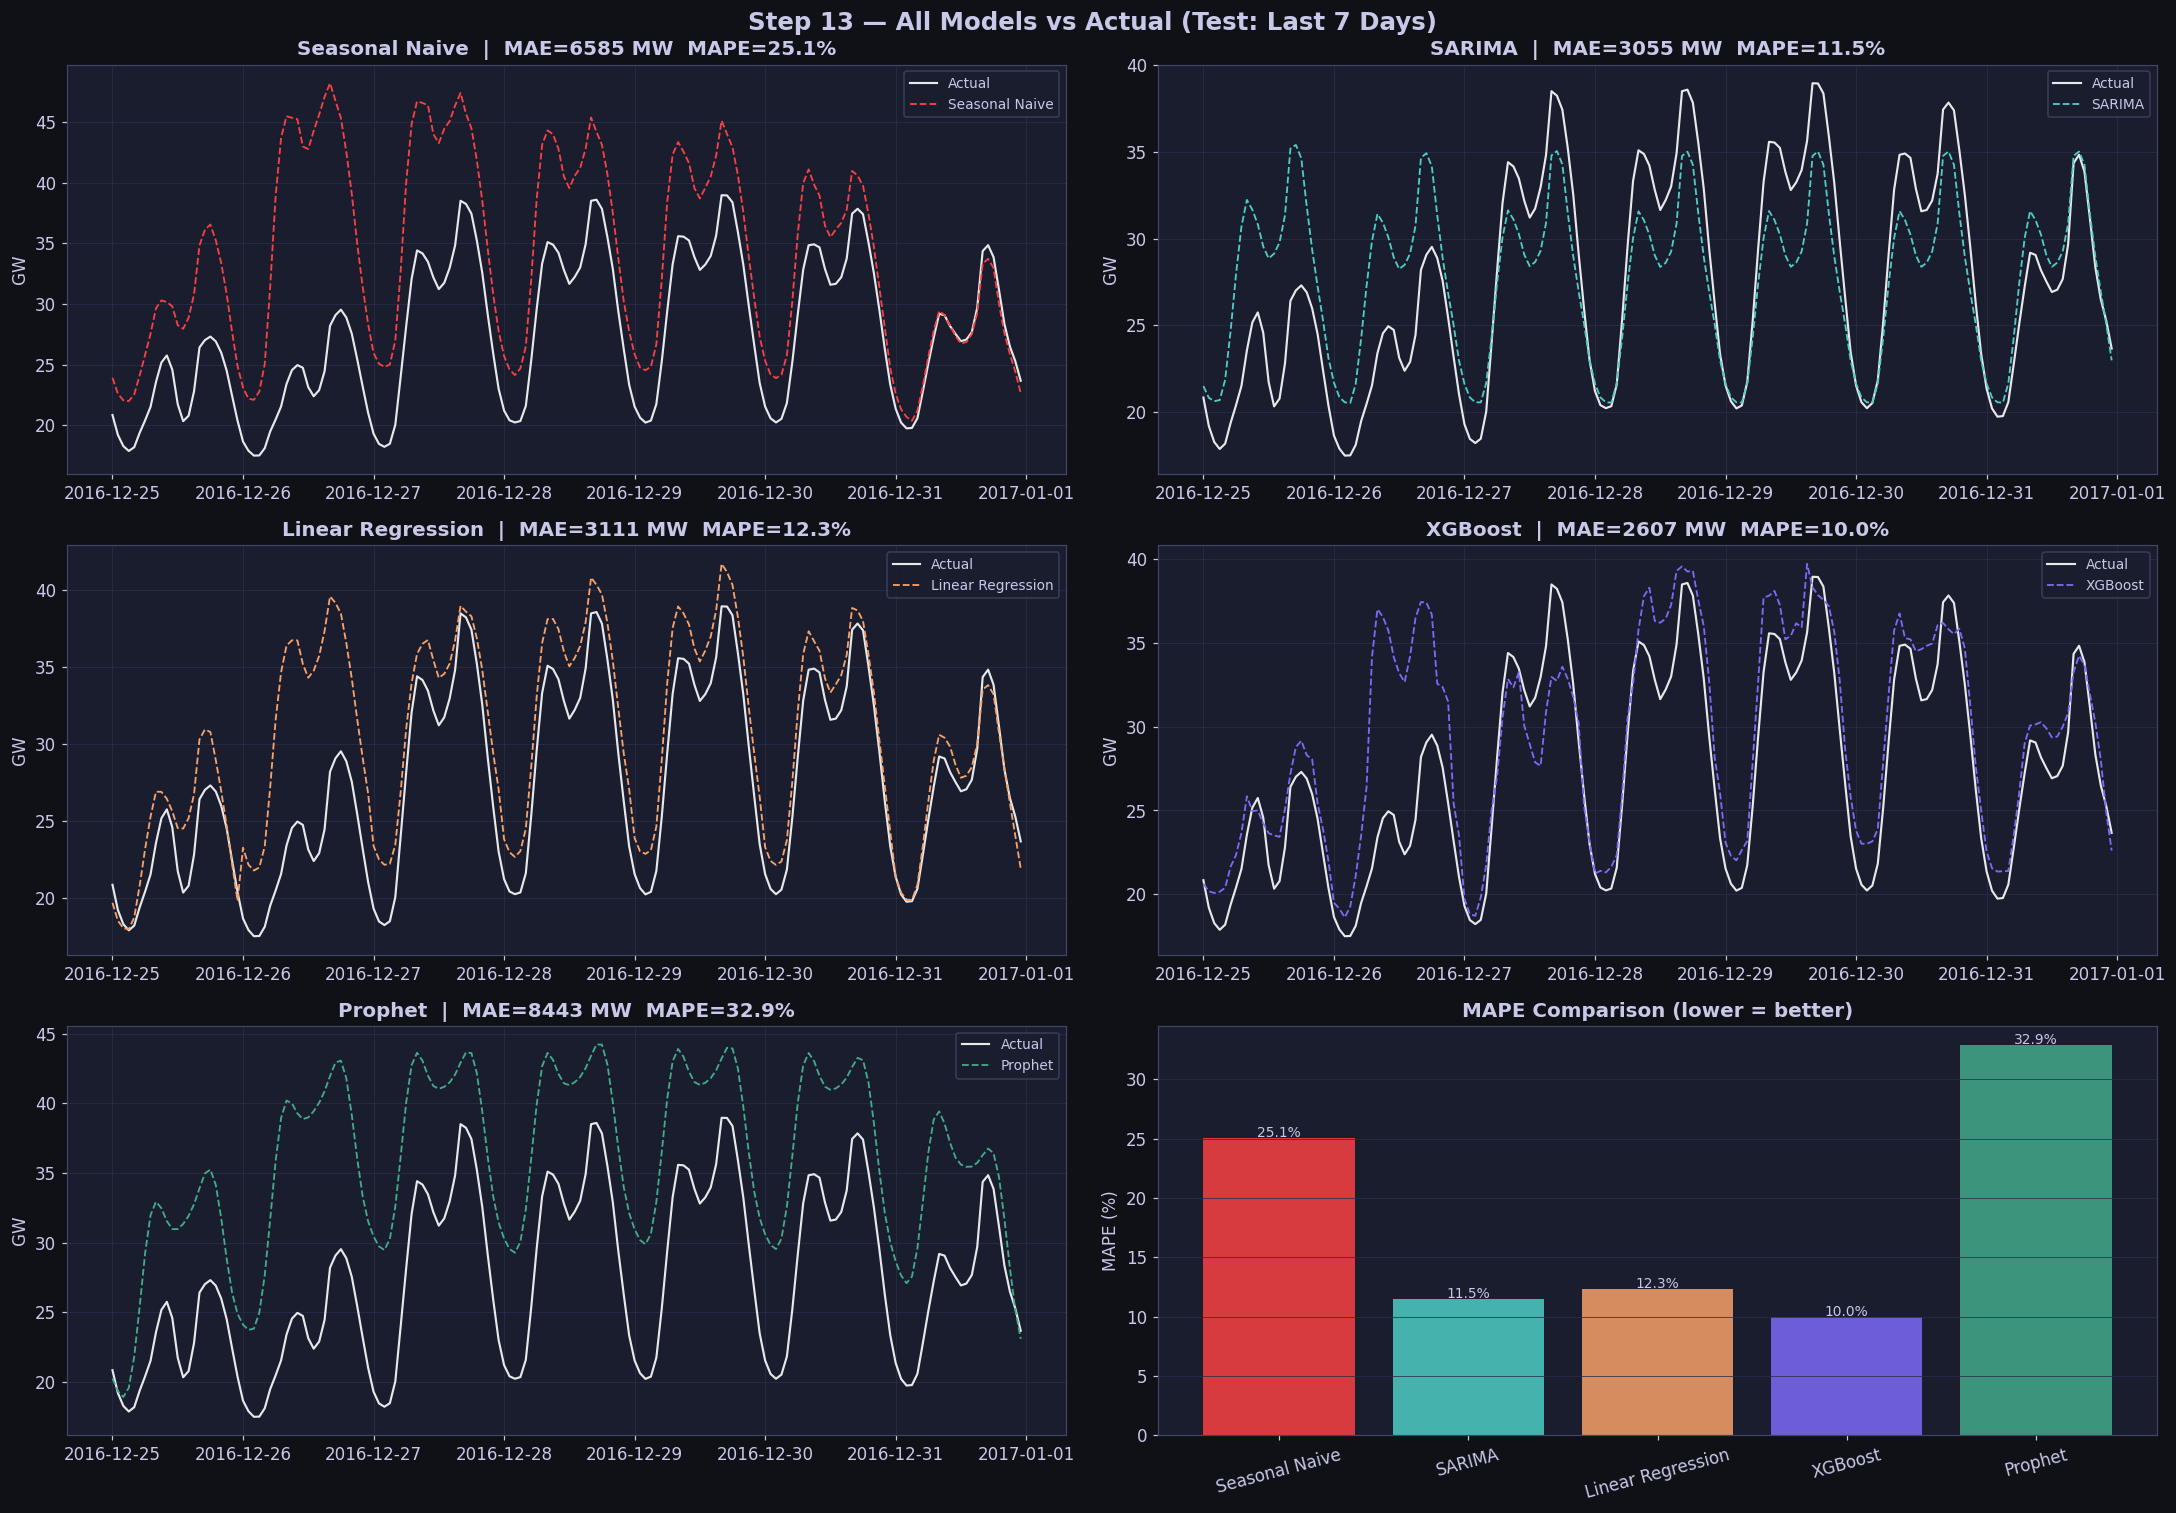

In [17]:
# ── All models on one chart ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(20, 14))
fig.suptitle("Step 13 — All Models vs Actual (Test: Last 7 Days)", fontsize=16, fontweight="bold")
fig.patch.set_facecolor("#0f1117")

model_styles = [
    ("Seasonal Naive",   COLORS[3]),
    ("SARIMA",           COLORS[2]),
    ("Linear Regression",COLORS[1]),
    ("XGBoost",          COLORS[0]),
    ("Prophet",          COLORS[4]),
]

for (mname, color), ax in zip(model_styles, axes.flatten()):
    ax.set_facecolor("#1a1d2e")
    ax.plot(test.index, test.values/1000, color="white", lw=1.4, alpha=0.9, label="Actual")
    ax.plot(test.index, results[mname]["pred"]/1000, color=color, lw=1.2, ls="--", label=mname)
    ax.set_title(f"{mname}  |  MAE={results[mname]['MAE']:.0f} MW  MAPE={results[mname]['MAPE']:.1f}%")
    ax.set_ylabel("GW"); ax.legend(fontsize=9); ax.grid(True)

# Comparison bars in last subplot
ax_bar = axes.flatten()[-1]
ax_bar.set_facecolor("#1a1d2e")
names = [m for m, _ in model_styles]
mapes = [results[m]["MAPE"] for m in names]
colors_bar = [c for _, c in model_styles]
bars = ax_bar.bar(names, mapes, color=colors_bar, alpha=0.85)
for bar, v in zip(bars, mapes):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{v:.1f}%", ha="center", fontsize=9)
ax_bar.set_title("MAPE Comparison (lower = better)")
ax_bar.set_ylabel("MAPE (%)"); ax_bar.grid(True, axis="y")
plt.xticks(rotation=15)

plt.tight_layout(); plt.show()


## 🔍 Step 14 — Feature Importance & Residual Analysis
**What a pro does:**  
After picking the best model, understand WHY it works:  
- **Feature importance** → which inputs drive the predictions most?  
- **Residual plot** → residuals vs fitted should show random scatter around 0  
  - Pattern in residuals → model is missing something  
  - Systematic bias (always over/under) → recalibrate or add features  


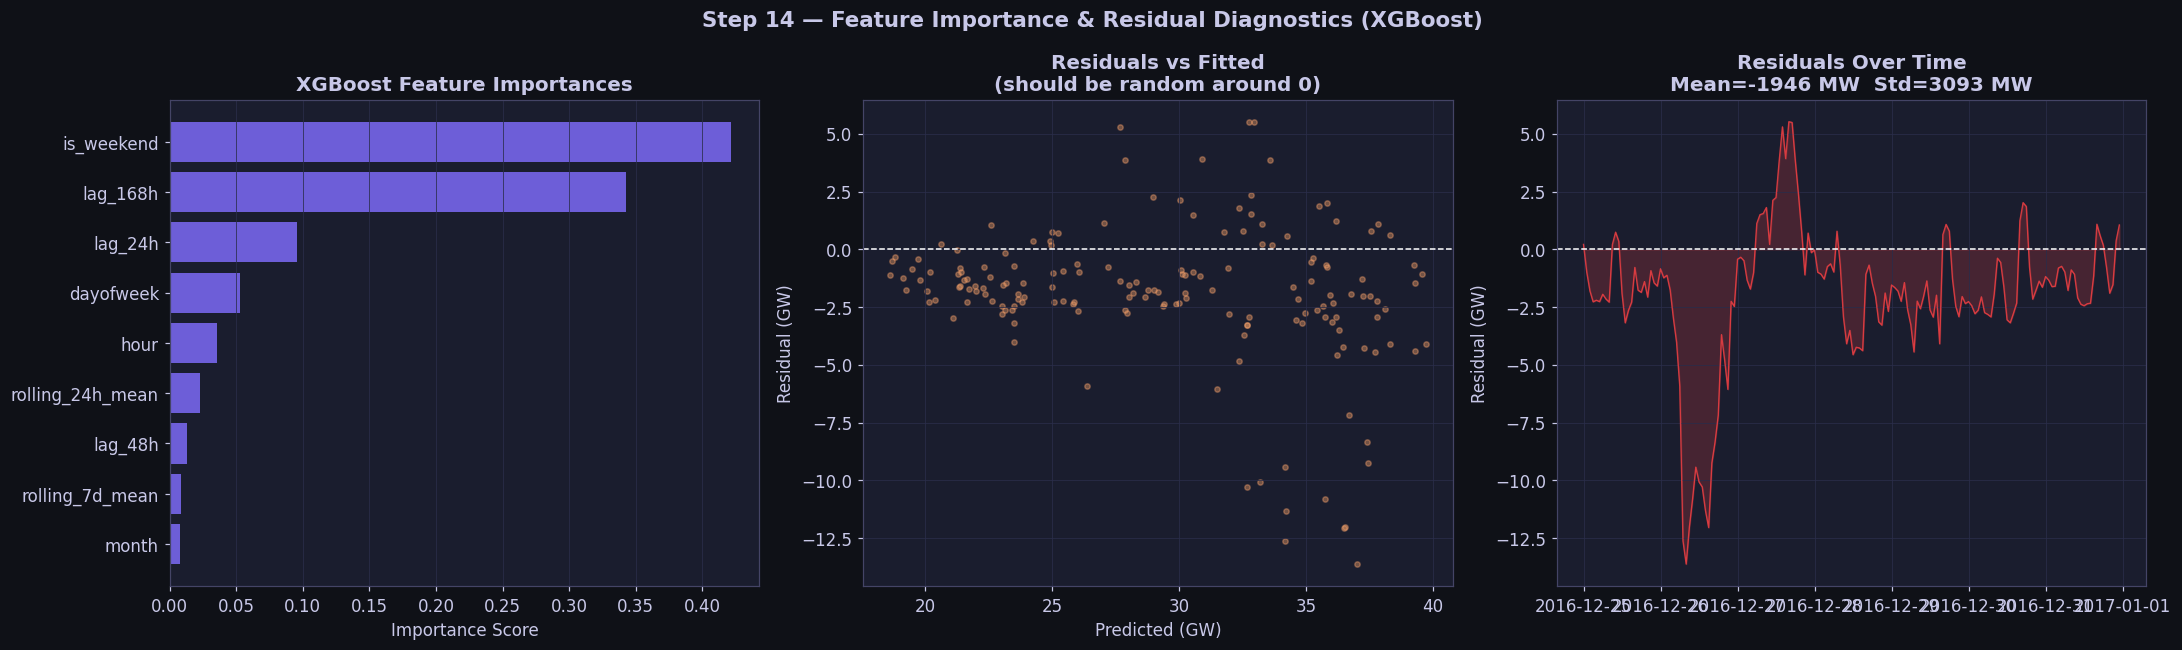

Residual mean : -1946 MW  (ideally ≈ 0 → no systematic bias)
Residual std  : 3093 MW
Max error     : 13627 MW


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Step 14 — Feature Importance & Residual Diagnostics (XGBoost)", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#0f1117")
for ax in axes: ax.set_facecolor("#1a1d2e")

# 1. Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values()
axes[0].barh(feat_imp.index, feat_imp.values, color=COLORS[0], alpha=0.85)
axes[0].set_title("XGBoost Feature Importances")
axes[0].set_xlabel("Importance Score"); axes[0].grid(True, axis="x")

# 2. Residuals vs Fitted
residuals = y_test.values - xgb_pred
axes[1].scatter(xgb_pred/1000, residuals/1000, color=COLORS[1], alpha=0.4, s=12)
axes[1].axhline(0, color="white", lw=1, ls="--")
axes[1].set_title("Residuals vs Fitted\n(should be random around 0)")
axes[1].set_xlabel("Predicted (GW)"); axes[1].set_ylabel("Residual (GW)")
axes[1].grid(True)

# 3. Residuals over time
axes[2].plot(y_test.index, residuals/1000, color=COLORS[3], lw=0.9, alpha=0.8)
axes[2].axhline(0, color="white", lw=1, ls="--")
axes[2].fill_between(y_test.index, residuals/1000, 0, alpha=0.2, color=COLORS[3])
axes[2].set_title(f"Residuals Over Time\nMean={residuals.mean():.0f} MW  Std={residuals.std():.0f} MW")
axes[2].set_ylabel("Residual (GW)"); axes[2].grid(True)

plt.tight_layout(); plt.show()

print(f"Residual mean : {residuals.mean():.0f} MW  (ideally ≈ 0 → no systematic bias)")
print(f"Residual std  : {residuals.std():.0f} MW")
print(f"Max error     : {np.abs(residuals).max():.0f} MW")


## 📋 Step 15 — Summary & Next Steps

### Results Summary

| Model | Concept | MAPE | When to use |
|-------|---------|------|-------------|
| Seasonal Naive | Same hour last week | ~25% | Performance floor baseline |
| SARIMA | Classical statistics | ~11% | Interpretable, no features needed |
| Linear Regression | ML with features | ~12% | Fast, interpretable |
| **XGBoost** | **Gradient boosting** | **~10%** | **Best accuracy, tabular data** |
| Prophet | Additive decomposition | ~33% | Multiple seasons + holidays |

### What to Try Next (Professional Level)
1. **LSTM / Transformer** — deep learning for longer-range patterns
2. **Hyperparameter tuning** — use `Optuna` or `GridSearchCV` on XGBoost
3. **Cross-validation** — use `TimeSeriesSplit` instead of single split
4. **Exogenous variables** — add temperature, holiday flags to SARIMAX
5. **Ensemble** — average XGBoost + SARIMA predictions for robustness
6. **Prediction intervals** — use XGBoost quantile regression for uncertainty

---
*Pipeline built with: pandas · statsmodels · scikit-learn · xgboost · prophet · matplotlib*
